C:\Users\harsh\AppData\Local\Temp\ipykernel_7680\2312243667.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


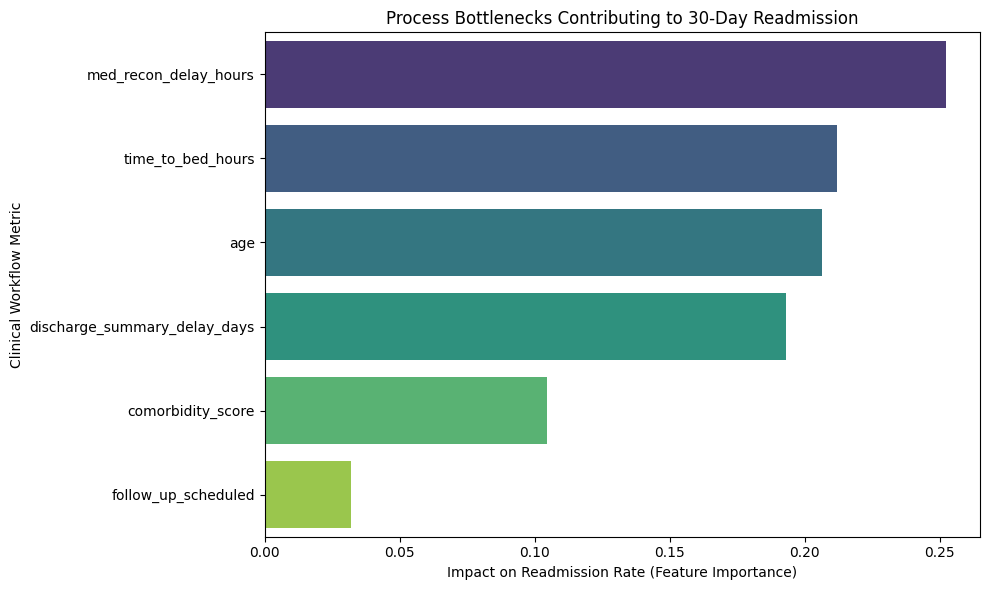

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data 
df = pd.read_csv('../data/synthetic_patient_flow_data.csv')

# 2. Prepare Data 
X = df.drop(['patient_id', 'readmitted_30_days'], axis=1)
y = df['readmitted_30_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Machine Learning Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Extract "Bottlenecks" 
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 5. Visualize the Results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Process Bottlenecks Contributing to 30-Day Readmission')
plt.xlabel('Impact on Readmission Rate (Feature Importance)')
plt.ylabel('Clinical Workflow Metric')
plt.tight_layout()

plt.savefig('../bottleneck_chart.png') 
plt.show()